# **Bubble Plots**


We will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

We will use various visualization techniques to explore the data and uncover key trends.


## Objectives


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [2]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [3]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


--2026-09-06 15:41:41--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  4.10MB/s    in 34s     

2026-09-06 15:42:15 (4.49 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


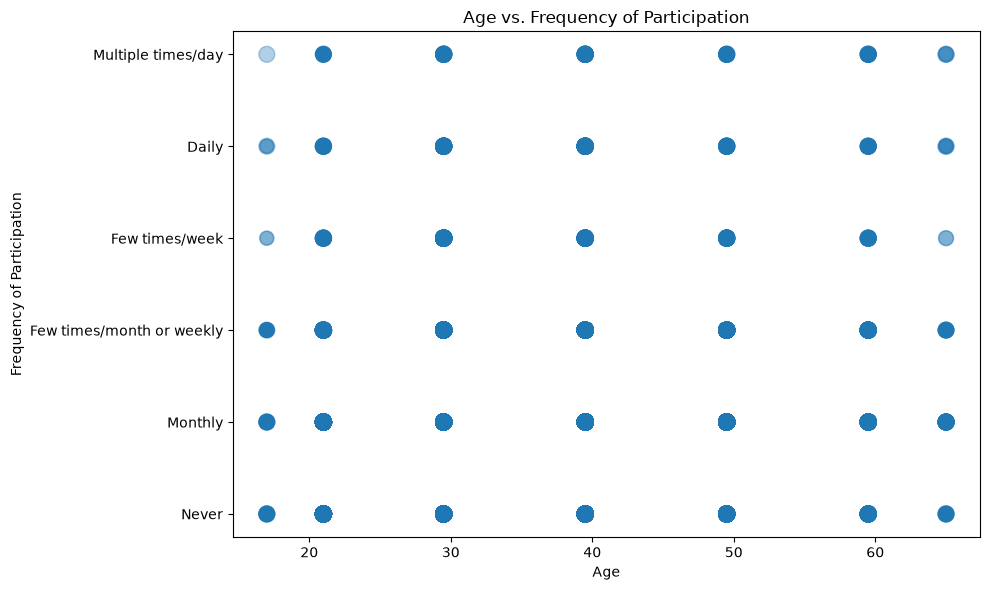

In [4]:
# Bubble Plot: Age vs. Frequency of Participation

age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

freq_map = {
    "I have never participated in Q&A on Stack Overflow": 0,
    "Less than once per month or monthly": 1,
    "A few times per month or weekly": 2,
    "A few times per week": 3,
    "Daily or almost daily": 4,
    "Multiple times per day": 5
}

plot_df = df[["Age", "SOPartFreq", "JobSat"]].copy()
plot_df["Age_numeric"] = plot_df["Age"].map(age_map)
plot_df["Participation"] = plot_df["SOPartFreq"].map(freq_map)
plot_df["JobSat"] = pd.to_numeric(plot_df["JobSat"], errors="coerce")
plot_df = plot_df.dropna()

plt.figure(figsize=(10, 6))
plt.scatter(
    plot_df["Age_numeric"],
    plot_df["Participation"],
    s=(plot_df["JobSat"] + 1) * 12,
    alpha=0.35
)
plt.xlabel("Age")
plt.ylabel("Frequency of Participation")
plt.title("Age vs. Frequency of Participation")
plt.yticks(
    range(6),
    ["Never", "Monthly", "Few times/month or weekly",
     "Few times/week", "Daily", "Multiple times/day"]
)
plt.tight_layout()
plt.show()


#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


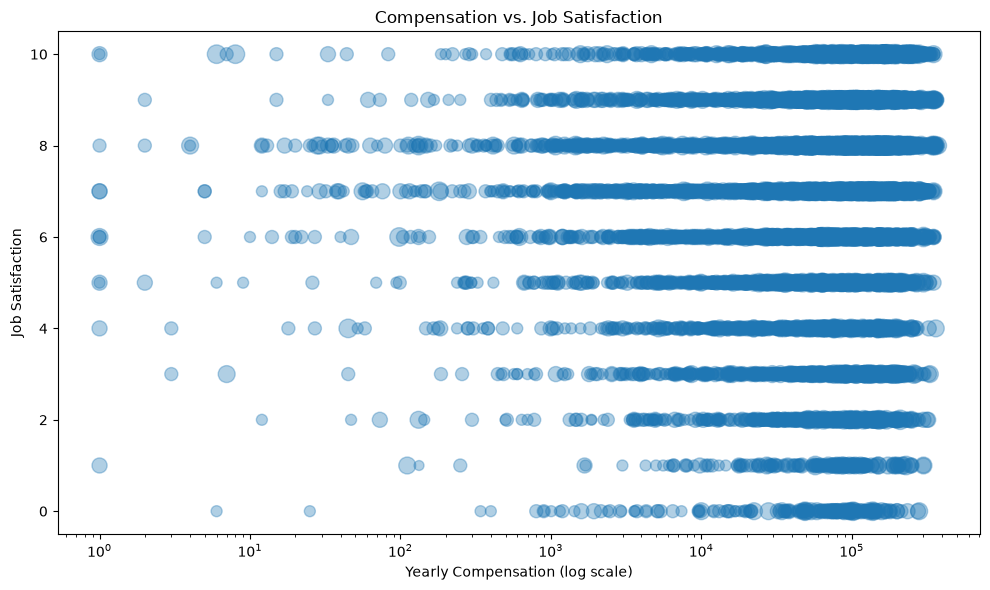

In [7]:
# Bubble Plot: Compensation vs. Job Satisfaction

plot_df = df[["ConvertedCompYearly", "JobSat", "Age"]].copy()
plot_df["ConvertedCompYearly"] = pd.to_numeric(plot_df["ConvertedCompYearly"], errors="coerce")
plot_df["JobSat"] = pd.to_numeric(plot_df["JobSat"], errors="coerce")
plot_df["Age_numeric"] = plot_df["Age"].map(age_map)
plot_df = plot_df.dropna()
plot_df = plot_df[plot_df["ConvertedCompYearly"] > 0]
plot_df = plot_df[plot_df["ConvertedCompYearly"] <= plot_df["ConvertedCompYearly"].quantile(0.99)]

plt.figure(figsize=(10, 6))
plt.scatter(
    plot_df["ConvertedCompYearly"],
    plot_df["JobSat"],
    s=plot_df["Age_numeric"] * 3,
    alpha=0.35
)
plt.xscale("log")
plt.xlabel("Yearly Compensation (log scale)")
plt.ylabel("Job Satisfaction")
plt.title("Compensation vs. Job Satisfaction")
plt.tight_layout()
plt.show()


### Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



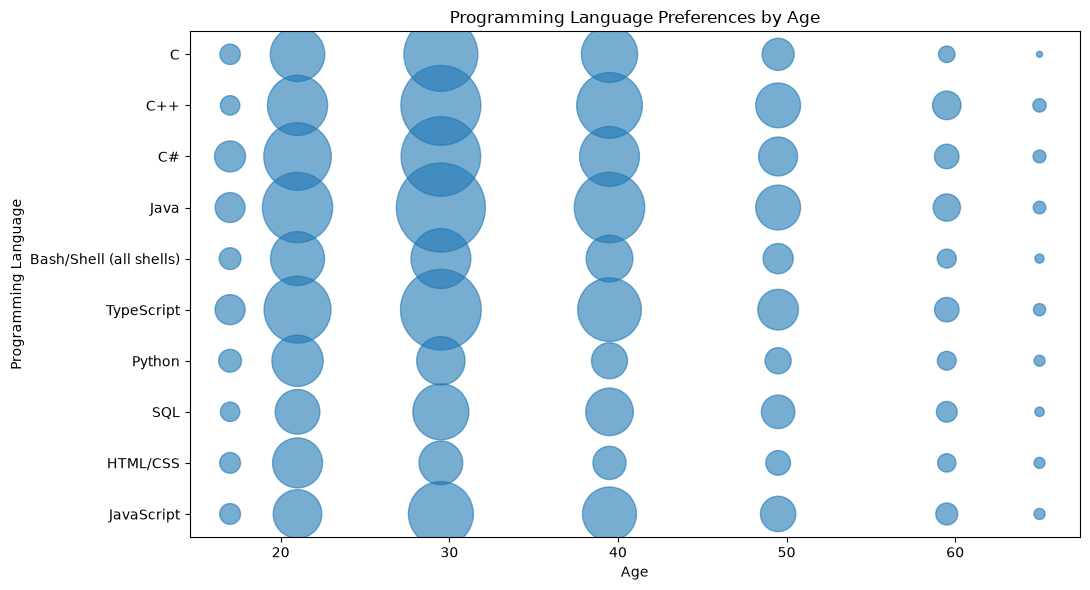

In [5]:
# Bubble Plot: Technology Preferences by Age

plot_df = df[["Age", "LanguageHaveWorkedWith"]].copy()
plot_df["Age_numeric"] = plot_df["Age"].map(age_map)
plot_df = plot_df.dropna(subset=["Age_numeric", "LanguageHaveWorkedWith"])

plot_df["Language"] = plot_df["LanguageHaveWorkedWith"].str.split(";")
plot_df = plot_df.explode("Language")

# Keep the 10 most common languages for readability
top_languages = plot_df["Language"].value_counts().head(10).index
plot_df = plot_df[plot_df["Language"].isin(top_languages)]

counts = plot_df.groupby(["Age", "Language"]).size().reset_index(name="Frequency")
counts["Age_numeric"] = counts["Age"].map(age_map)

plt.figure(figsize=(11, 6))
plt.scatter(
    counts["Age_numeric"],
    counts["Language"].astype("category").cat.codes,
    s=counts["Frequency"] * 0.3,
    alpha=0.6
)
plt.xlabel("Age")
plt.ylabel("Programming Language")
plt.title("Programming Language Preferences by Age")
plt.yticks(
    range(len(top_languages)),
    sorted(top_languages, key=lambda x: list(top_languages).index(x))
)
plt.tight_layout()
plt.show()


#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


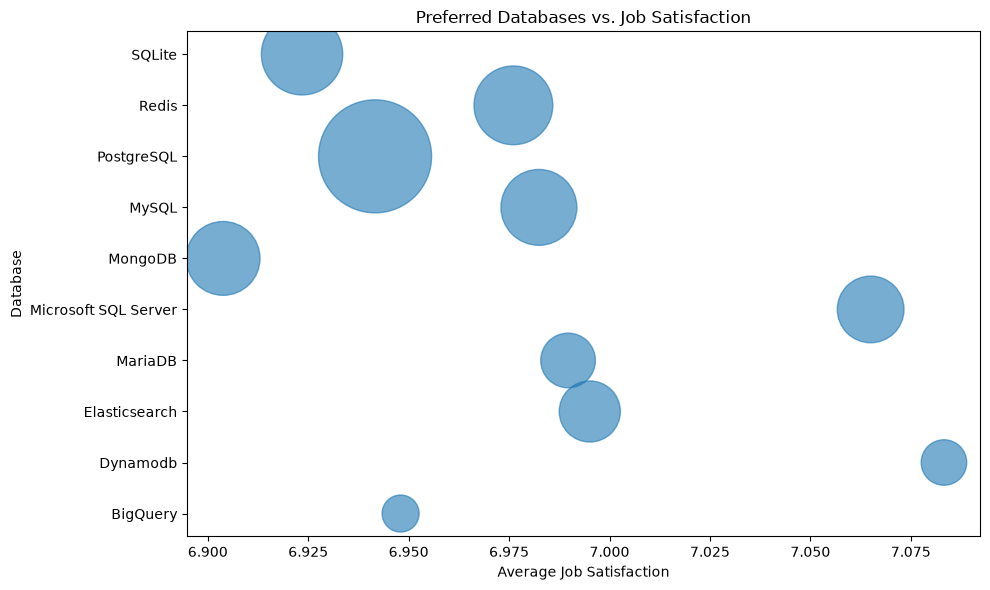

In [6]:
# Bubble Plot: Preferred Databases vs. Job Satisfaction

plot_df = df[["DatabaseWantToWorkWith", "JobSat"]].copy()
plot_df["JobSat"] = pd.to_numeric(plot_df["JobSat"], errors="coerce")
plot_df = plot_df.dropna(subset=["DatabaseWantToWorkWith", "JobSat"])

plot_df["Database"] = plot_df["DatabaseWantToWorkWith"].str.split(";")
plot_df = plot_df.explode("Database")

top_databases = plot_df["Database"].value_counts().head(10).index
plot_df = plot_df[plot_df["Database"].isin(top_databases)]

summary = plot_df.groupby("Database").agg(
    AverageJobSat=("JobSat", "mean"),
    Frequency=("JobSat", "size")
).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(
    summary["AverageJobSat"],
    summary["Database"].astype("category").cat.codes,
    s=summary["Frequency"] * 0.5,
    alpha=0.6
)
plt.xlabel("Average Job Satisfaction")
plt.ylabel("Database")
plt.title("Preferred Databases vs. Job Satisfaction")
plt.yticks(range(len(summary)), summary["Database"])
plt.tight_layout()
plt.show()


### Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


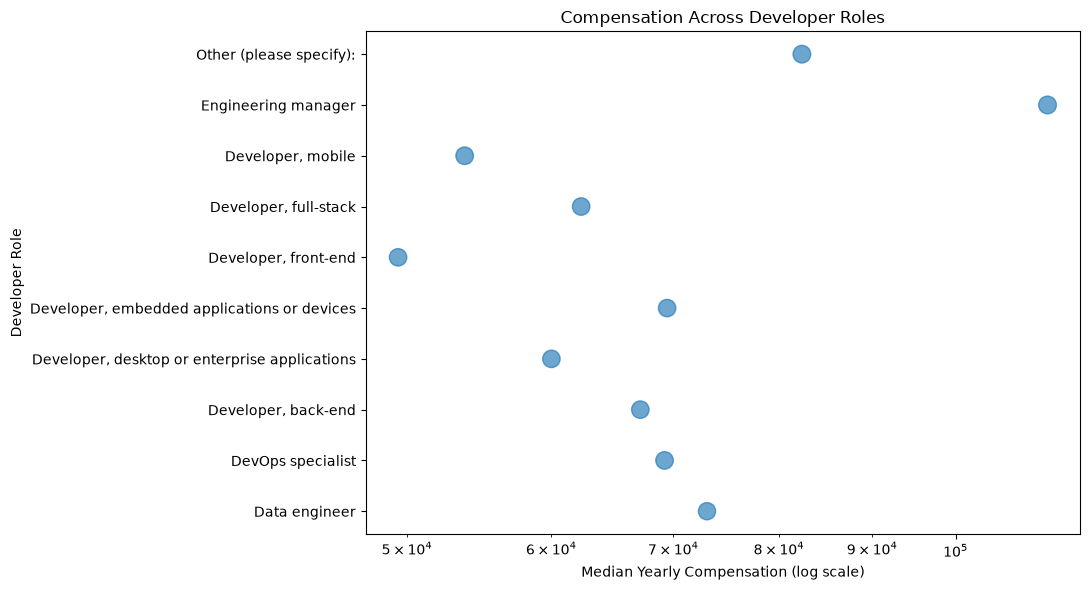

In [10]:
# Bubble Plot: Compensation Across Developer Roles

plot_df = df[["DevType", "ConvertedCompYearly", "JobSat"]].copy()
plot_df["ConvertedCompYearly"] = pd.to_numeric(plot_df["ConvertedCompYearly"], errors="coerce")
plot_df["JobSat"] = pd.to_numeric(plot_df["JobSat"], errors="coerce")
plot_df = plot_df.dropna(subset=["DevType", "ConvertedCompYearly", "JobSat"])
plot_df = plot_df[plot_df["ConvertedCompYearly"] > 0]

plot_df["Role"] = plot_df["DevType"].str.split(";")
plot_df = plot_df.explode("Role")

# Keep the 10 most common roles
top_roles = plot_df["Role"].value_counts().head(10).index
plot_df = plot_df[plot_df["Role"].isin(top_roles)]
plot_df = plot_df[plot_df["ConvertedCompYearly"] <= plot_df["ConvertedCompYearly"].quantile(0.99)]

summary = plot_df.groupby("Role").agg(
    MedianCompensation=("ConvertedCompYearly", "median"),
    AverageJobSat=("JobSat", "mean")
).reset_index()

plt.figure(figsize=(11, 6))
plt.scatter(
    summary["MedianCompensation"],
    summary["Role"].astype("category").cat.codes,
    s=(summary["AverageJobSat"] + 1) * 20,
    alpha=0.65
)
plt.xscale("log")
plt.xlabel("Median Yearly Compensation (log scale)")
plt.ylabel("Developer Role")
plt.title("Compensation Across Developer Roles")
plt.yticks(range(len(summary)), summary["Role"])
plt.tight_layout()
plt.show()


#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


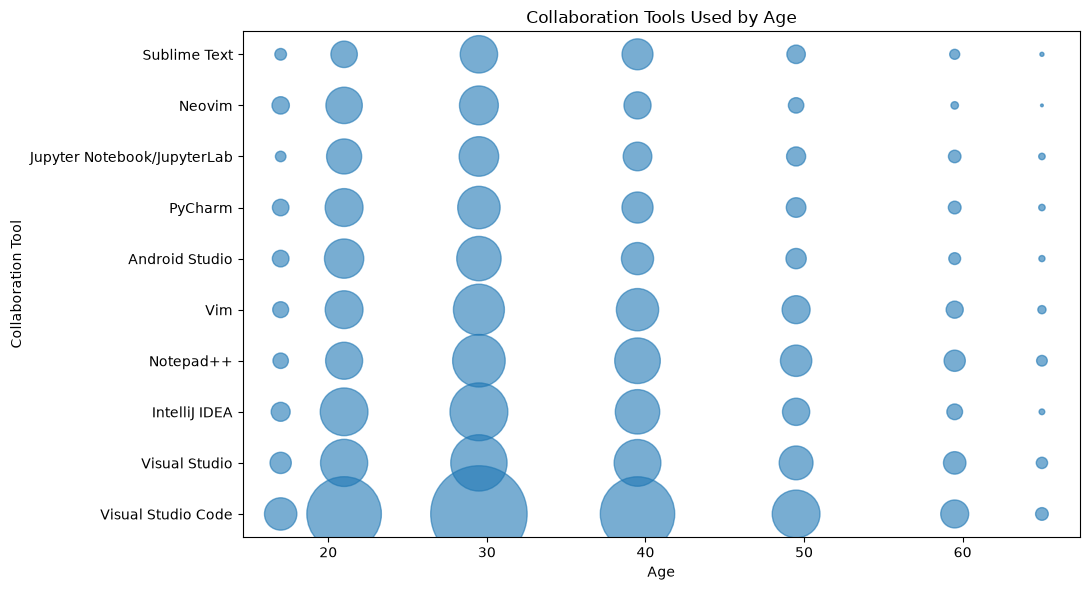

In [7]:
# Bubble Plot: Collaboration Tools by Age

plot_df = df[["Age", "NEWCollabToolsHaveWorkedWith"]].copy()
plot_df["Age_numeric"] = plot_df["Age"].map(age_map)
plot_df = plot_df.dropna(subset=["Age_numeric", "NEWCollabToolsHaveWorkedWith"])

plot_df["Tool"] = plot_df["NEWCollabToolsHaveWorkedWith"].str.split(";")
plot_df = plot_df.explode("Tool")

top_tools = plot_df["Tool"].value_counts().head(10).index
plot_df = plot_df[plot_df["Tool"].isin(top_tools)]

counts = plot_df.groupby(["Age", "Tool"]).size().reset_index(name="Frequency")
counts["Age_numeric"] = counts["Age"].map(age_map)

tools = list(top_tools)
tool_codes = {tool: i for i, tool in enumerate(tools)}
counts["Tool_code"] = counts["Tool"].map(tool_codes)

plt.figure(figsize=(11, 6))
plt.scatter(
    counts["Age_numeric"],
    counts["Tool_code"],
    s=counts["Frequency"] * 0.3,
    alpha=0.6
)
plt.xlabel("Age")
plt.ylabel("Collaboration Tool")
plt.title("Collaboration Tools Used by Age")
plt.yticks(range(len(tools)), tools)
plt.tight_layout()
plt.show()


### Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



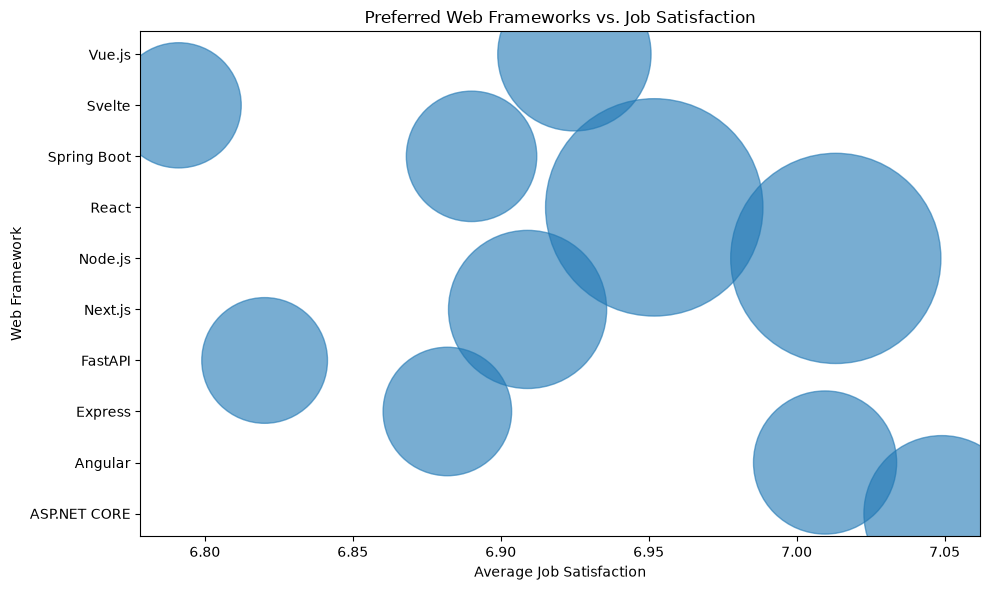

In [12]:
# Bubble Plot: Preferred Web Frameworks vs. Job Satisfaction

plot_df = df[["WebframeWantToWorkWith", "JobSat"]].copy()
plot_df["JobSat"] = pd.to_numeric(plot_df["JobSat"], errors="coerce")
plot_df = plot_df.dropna(subset=["WebframeWantToWorkWith", "JobSat"])

plot_df["Framework"] = plot_df["WebframeWantToWorkWith"].str.split(";")
plot_df = plot_df.explode("Framework")

top_frameworks = plot_df["Framework"].value_counts().head(10).index
plot_df = plot_df[plot_df["Framework"].isin(top_frameworks)]

summary = plot_df.groupby("Framework").agg(
    AverageJobSat=("JobSat", "mean"),
    Frequency=("JobSat", "size")
).reset_index()

plt.figure(figsize=(10, 6))
plt.scatter(
    summary["AverageJobSat"],
    summary["Framework"].astype("category").cat.codes,
    s=summary["Frequency"] * 3,
    alpha=0.6
)
plt.xlabel("Average Job Satisfaction")
plt.ylabel("Web Framework")
plt.title("Preferred Web Frameworks vs. Job Satisfaction")
plt.yticks(range(len(summary)), summary["Framework"])
plt.tight_layout()
plt.show()


#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



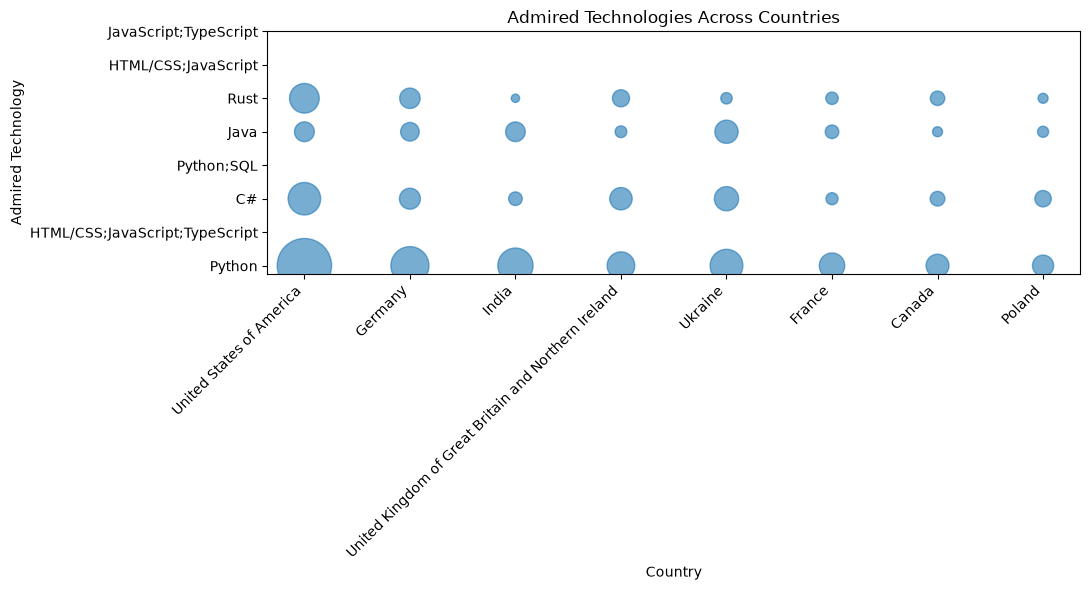

In [13]:
# Bubble Plot: Admired Technologies Across Countries

plot_df = df[["Country", "LanguageAdmired"]].copy()
plot_df = plot_df.dropna(subset=["Country", "LanguageAdmired"])

# Keep the 8 most common countries and 8 most admired languages
top_countries = plot_df["Country"].value_counts().head(8).index
top_languages = plot_df["LanguageAdmired"].value_counts().head(8).index

plot_df = plot_df[
    plot_df["Country"].isin(top_countries) &
    plot_df["LanguageAdmired"].isin(top_languages)
]

plot_df["Technology"] = plot_df["LanguageAdmired"].str.split(";")
plot_df = plot_df.explode("Technology")
plot_df = plot_df[plot_df["Technology"].isin(top_languages)]

counts = plot_df.groupby(["Country", "Technology"]).size().reset_index(name="Frequency")

country_codes = {country: i for i, country in enumerate(top_countries)}
tech_codes = {tech: i for i, tech in enumerate(top_languages)}

counts["Country_code"] = counts["Country"].map(country_codes)
counts["Technology_code"] = counts["Technology"].map(tech_codes)

plt.figure(figsize=(11, 6))
plt.scatter(
    counts["Country_code"],
    counts["Technology_code"],
    s=counts["Frequency"] * 4,
    alpha=0.6
)
plt.xlabel("Country")
plt.ylabel("Admired Technology")
plt.title("Admired Technologies Across Countries")
plt.xticks(range(len(top_countries)), top_countries, rotation=45, ha="right")
plt.yticks(range(len(top_languages)), top_languages)
plt.tight_layout()
plt.show()


## Summary


- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.
